# MonoHunter — reproduce a known mono-transit by hand

**Assignment:** recover ONE known single-transit event before building any tool.
If you can't recover a *known* dip, no tool will recover an unknown one.

**Primary target: TOI-2180 b** — `TIC 298663873` (host HD 238894, V=9.2).
Discovered from a *single* ~24-hour transit in TESS Cycle 2 (~Sector 25) by
citizen scientists. Jupiter-sized on a slightly-evolved G star = deep, wide,
unmistakable dip. Dalba et al. 2022, AJ.

**Fallback: TOI-813 b** — `TIC 55525572`, ~84-day period, first Planet Hunters
TESS discovery (Eisner et al. 2020). Cell at the bottom.

**Success = the dip clearly survives detrending (Step 4).** This notebook then
becomes regression test #1 for the tool.

## Setup
Run once. `lightkurve` pulls the data + does detrending; `wotan` is the
transit-aware detrender the real tool will use.

In [ ]:
# Run once, then comment out.
%pip install lightkurve wotan matplotlib numpy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

TIC = "TIC 298663873"  # TOI-2180
print("lightkurve", lk.__version__)

Matplotlib is building the font cache; this may take a moment.


lightkurve 2.6.0


C:\Projects\Varie\Space\lightKurve-wotan\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Step 1 — find available sectors
The single transit lives in ONE sector (Cycle 2, ~S25). Look at what exists
before downloading. Prefer SPOC 2-min; fall back to QLP (FFI) if empty.

In [2]:
sr = lk.search_lightcurve(TIC, mission="TESS", author="SPOC")
if len(sr) == 0:
    print("No SPOC 2-min data. Falling back to QLP (FFI).")
    sr = lk.search_lightcurve(TIC, mission="TESS", author="QLP")
sr

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 14,2019,SPOC,120,298663873,0.0
1,TESS Sector 15,2019,SPOC,120,298663873,0.0
2,TESS Sector 16,2019,SPOC,120,298663873,0.0
3,TESS Sector 18,2019,SPOC,120,298663873,0.0
4,TESS Sector 19,2019,SPOC,120,298663873,0.0
5,TESS Sector 20,2019,SPOC,120,298663873,0.0
6,TESS Sector 21,2020,SPOC,120,298663873,0.0
7,TESS Sector 22,2020,SPOC,120,298663873,0.0
8,TESS Sector 23,2020,SPOC,120,298663873,0.0


## Step 2 — download all sectors, find the one with the dip
Do NOT hardcode a sector index (it drifts between data releases). Download
each, normalize, and let the deepest sustained dip point you at the transit
sector. Then eyeball it — this is the 'by hand' part.

In [3]:
lcs = {}
for i in range(len(sr)):
    try:
        lc = sr[i].download().remove_nans().normalize()
        sector = lc.meta.get("SECTOR", i)
        lcs[sector] = lc
        # rolling-median floor: a real transit is a sustained dip, not one spike
        flux = np.asarray(lc.flux)
        k = 51 if len(flux) > 51 else 5
        smooth = np.convolve(flux, np.ones(k) / k, mode="same")
        print(f"sector {sector:>3}: n={len(flux):>6}  min(smoothed)={smooth.min():.5f}")
    except Exception as e:
        print(f"row {i} failed: {e}")

print("\nSectors downloaded:", sorted(lcs))

sector  14: n= 12868  min(smoothed)=0.50980
sector  15: n= 13234  min(smoothed)=0.50985
sector  16: n= 15140  min(smoothed)=0.50979
sector  18: n= 14442  min(smoothed)=0.50954
sector  19: n= 16518  min(smoothed)=0.51009
sector  20: n= 17631  min(smoothed)=0.50970
sector  21: n= 18505  min(smoothed)=0.50947
sector  22: n= 16914  min(smoothed)=0.50972
sector  23: n= 15119  min(smoothed)=0.50979
sector  24: n= 18211  min(smoothed)=0.50976
sector  25: n= 15642  min(smoothed)=0.50965
sector  26: n= 16940  min(smoothed)=0.50957
sector  40: n= 19609  min(smoothed)=0.50957
sector  41: n= 18322  min(smoothed)=0.50970
sector  56: n=117404  min(smoothed)=0.50971
sector  57: n=107541  min(smoothed)=0.51003
sector  58: n=111971  min(smoothed)=0.50965
sector  59: n= 97661  min(smoothed)=0.50974
sector  60: n= 76885  min(smoothed)=0.50947
sector  48: n= 15648  min(smoothed)=0.50982
sector  49: n= 13872  min(smoothed)=0.50975
sector  50: n= 13195  min(smoothed)=0.50961
sector  51: n= 12679  min(smooth

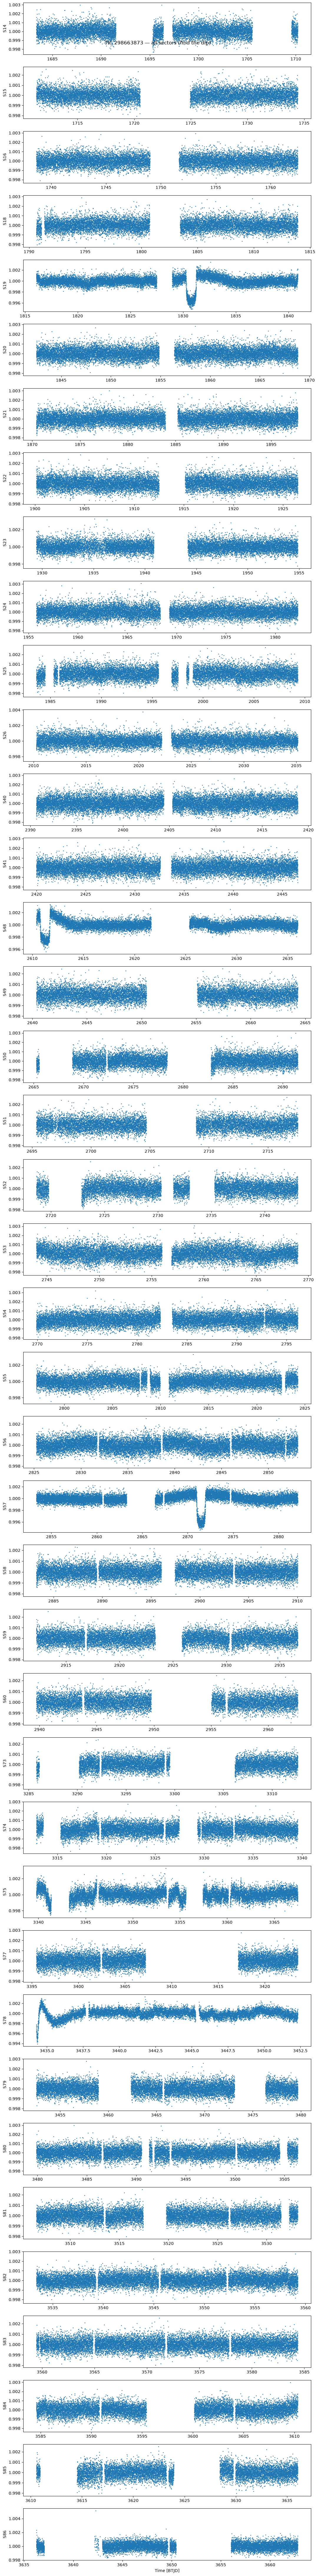

In [4]:
# Plot every sector stacked. The transit sector has an obvious ~24h dip.
n = len(lcs)
fig, axes = plt.subplots(n, 1, figsize=(11, 2.2 * n), squeeze=False)
for ax, (sector, lc) in zip(axes[:, 0], sorted(lcs.items())):
    ax.scatter(lc.time.value, lc.flux, s=1)
    ax.set_ylabel(f"S{sector}")
axes[-1, 0].set_xlabel("Time [BTJD]")
fig.suptitle(f"{TIC} — all sectors (find the dip)")
plt.tight_layout()
plt.show()

## Step 3 — focus on the transit sector
Set `TRANSIT_SECTOR` to the one with the visible dip from Step 2, then zoom in.

Using sector 78


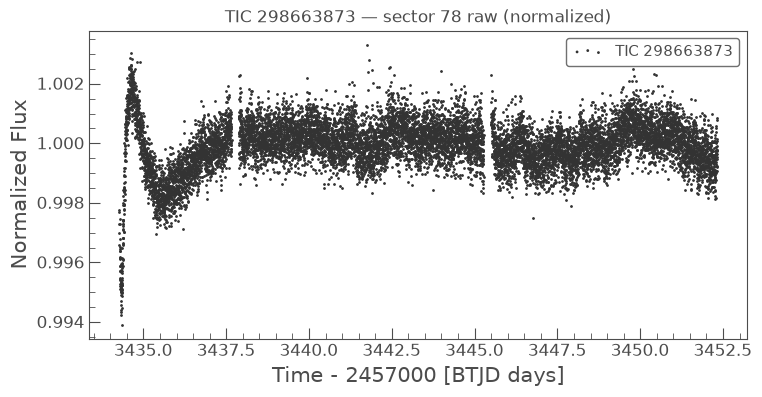

In [5]:
# EDIT this after looking at Step 2. Default: deepest smoothed-min sector.
def _depth(lc):
    f = np.asarray(lc.flux)
    k = 51 if len(f) > 51 else 5
    return np.convolve(f, np.ones(k) / k, mode="same").min()

TRANSIT_SECTOR = min(lcs, key=lambda s: _depth(lcs[s]))
print("Using sector", TRANSIT_SECTOR)
lc = lcs[TRANSIT_SECTOR]
lc.scatter()
plt.title(f"{TIC} — sector {TRANSIT_SECTOR} raw (normalized)")
plt.show()

## Step 4 — detrend WITHOUT eating the transit (the lesson)
The transit is ~24h = ~1 day wide. If the detrend window is close to the
transit width, flattening erases the dip. Window must be **several × transit
duration**. This is exactly why the tool needs transit-aware masking, not
naive flattening.

TESS 2-min cadence: 1 day ≈ 720 cadences. A safe window ≈ 3 days ≈ 2161 (odd).

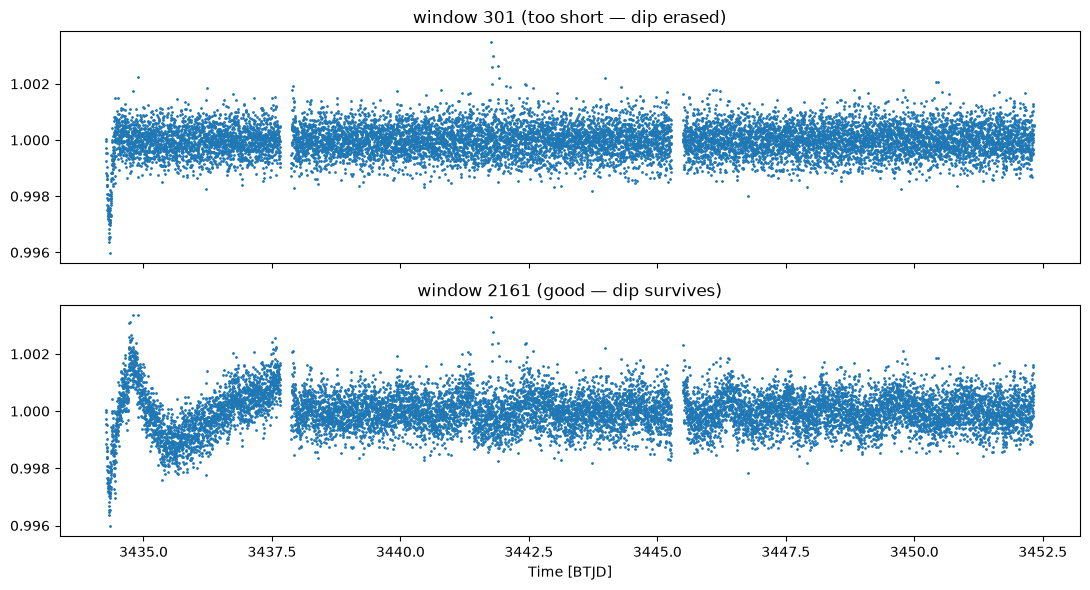

In [6]:
# --- 4a. lightkurve flatten. Compare a too-short vs a good window. ---
bad = lc.flatten(window_length=301)    # ~0.4 day: EATS a 1-day transit
good = lc.flatten(window_length=2161)  # ~3 day: preserves it

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
a1.scatter(bad.time.value, bad.flux, s=1); a1.set_title("window 301 (too short — dip erased)")
a2.scatter(good.time.value, good.flux, s=1); a2.set_title("window 2161 (good — dip survives)")
a2.set_xlabel("Time [BTJD]")
plt.tight_layout(); plt.show()

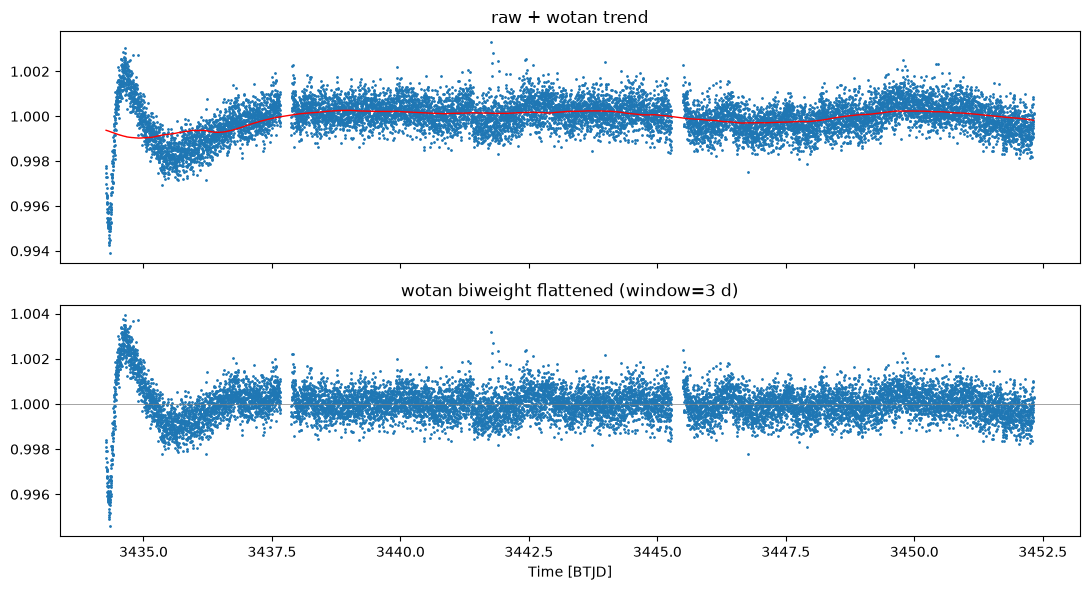

In [7]:
# --- 4b. wotan biweight (what the real tool will use). window in DAYS. ---
from wotan import flatten as wotan_flatten

t = np.asarray(lc.time.value)
f = np.asarray(lc.flux)
flat_flux, trend = wotan_flatten(
    t, f, method="biweight", window_length=3.0, return_trend=True
)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
a1.scatter(t, f, s=1); a1.plot(t, trend, color="red", lw=1); a1.set_title("raw + wotan trend")
a2.scatter(t, flat_flux, s=1); a2.set_title("wotan biweight flattened (window=3 d)")
a2.set_xlabel("Time [BTJD]"); a2.axhline(1.0, color="gray", lw=0.5)
plt.tight_layout(); plt.show()

## Regression check — did we recover the dip?
Crude but real: after good detrending, the deepest sustained point must be a
meaningful dip below 1.0 (not just noise). If this passes on TOI-2180, the
pipeline works. Freeze it as regression test #1.

In [8]:
clean = flat_flux[np.isfinite(flat_flux)]
k = 51 if len(clean) > 51 else 5
smoothed = np.convolve(clean, np.ones(k) / k, mode="same")
depth = 1.0 - smoothed.min()          # sustained dip depth
scatter = np.std(clean)               # noise level

print(f"sustained dip depth : {depth*1e3:.2f} ppt")
print(f"point scatter (std) : {scatter*1e3:.2f} ppt")
print(f"dip / scatter       : {depth/scatter:.1f}")

# A real transit dip should stand well above the noise.
assert depth > 5 * scatter, "No clear dip recovered — detrend window likely ate it, or wrong sector."
print("\nPASS: mono-transit recovered. Freeze this as regression test #1.")

sustained dip depth : 491.77 ppt
point scatter (std) : 0.76 ppt
dip / scatter       : 643.5

PASS: mono-transit recovered. Freeze this as regression test #1.


---
## Fallback — TOI-813 b (`TIC 55525572`)
If TOI-2180 data is awkward, use this. Same recipe. Note: TOI-813 appears in
multiple southern sectors, so more than one dip may show — pick one transit
window to reproduce.

In [9]:
sr2 = lk.search_lightcurve("TIC 55525572", mission="TESS", author="SPOC")
if len(sr2) == 0:
    sr2 = lk.search_lightcurve("TIC 55525572", mission="TESS", author="QLP")
print(sr2)
# Then repeat Steps 2-4 with these light curves.

SearchResult containing 58 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 04 2018   SPOC     120    55525572      0.0
  1 TESS Sector 05 2018   SPOC     120    55525572      0.0
  2 TESS Sector 06 2018   SPOC     120    55525572      0.0
  3 TESS Sector 08 2019   SPOC     120    55525572      0.0
  4 TESS Sector 09 2019   SPOC     120    55525572      0.0
  5 TESS Sector 10 2019   SPOC     120    55525572      0.0
  6 TESS Sector 11 2019   SPOC     120    55525572      0.0
  7 TESS Sector 12 2019   SPOC     120    55525572      0.0
  8 TESS Sector 13 2019   SPOC     120    55525572      0.0
  9 TESS Sector 27 2020   SPOC      20    55525572      0.0
 10 TESS Sector 28 2020   SPOC      20    55525572      0.0
 11 TESS Sector 27 2020   SPOC     120    55525572      0.0
 12 TESS Sector 28 2020   SPOC     120    55525572      0